# Explainable AI (XAI) for Audio Deepfake Detection

This notebook demonstrates various explainability methods for understanding model predictions:

| Method | Description |
|--------|-------------|
| **Grad-CAM** | Gradient-weighted Class Activation Mapping - shows which regions influenced the prediction |
| **SHAP** | SHapley Additive exPlanations - game-theoretic feature attribution |
| **TCAV** | Testing with Concept Activation Vectors - tests importance of human-defined concepts |
| **Analysis** | Frequency band and temporal pattern analysis |

## Setup

In [ ]:
# Install SHAP if not available
# !pip install shap --quiet

## 1. Grad-CAM Analysis

Gradient-weighted Class Activation Mapping shows which spectrogram regions most influenced the model's prediction.

In [ ]:
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1   --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav"  --show --method gradcam

In [ ]:
%run explain.py --config config/ensemble.conf --feature_type 1   --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav"  --show --method gradcam

In [ ]:
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1   --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/real/file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav"  --show --method gradcam

In [ ]:
%run explain.py --config config/ensemble.conf --feature_type 1   --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/real/file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav"  --show --method gradcam

## 2. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded feature attributions based on game theory.

In [ ]:
# SHAP analysis on a FAKE audio sample
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method shap

In [ ]:
# SHAP analysis on a REAL audio sample
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/real/file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method shap

## 3. TCAV Analysis

Testing with Concept Activation Vectors (TCAV) provides concept-based explanations. Unlike pixel-level methods like Grad-CAM, TCAV tests whether high-level concepts (e.g., "high-frequency artifacts", "temporal discontinuities") are important to the model's predictions.

### Audio Concepts Tested:
- **High-frequency artifacts**: Synthesis artifacts common in fake audio
- **Low-frequency energy**: Fundamental frequency patterns
- **Temporal discontinuity**: Glitches or unnatural transitions
- **Noise floor**: Background noise characteristics
- **Harmonic structure**: Natural voice harmonic patterns
- **Spectral flatness**: Tonal vs. noise-like characteristics

Using device: cpu
Loading weights from: ./models/weights/EfficientNetB2_Attention_swa.pth

Running XAI Analysis on: EfficientNetB2_Attention_file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: tcav
Output directory: explained_outputs
Display mode: Interactive matplotlib windows

[TCAV] Running Concept-Based Analysis...
  Prediction: FAKE (confidence: 79.9%)
  Explaining class: 0 (FAKE)
     Selected EfficientNet features[-1]
     Refined Sequential to last Conv layer: Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  Using layer: Conv2d
  Testing 6 audio concepts...
  Processing concept: high_freq_artifacts
    CAV accuracy: 91.67%, TCAV score: 0.799
  Processing concept: low_freq_energy
    CAV accuracy: 100.00%, TCAV score: 0.799
  Processing concept: temporal_discontinuity
    CAV accuracy: 100.00%, TCAV score: 0.799
  Processing concept: noise_floor
    CAV accuracy: 100.00%, TCAV score: 0.799
  Processing concept: harmonic_structure
    CAV accuracy: 10

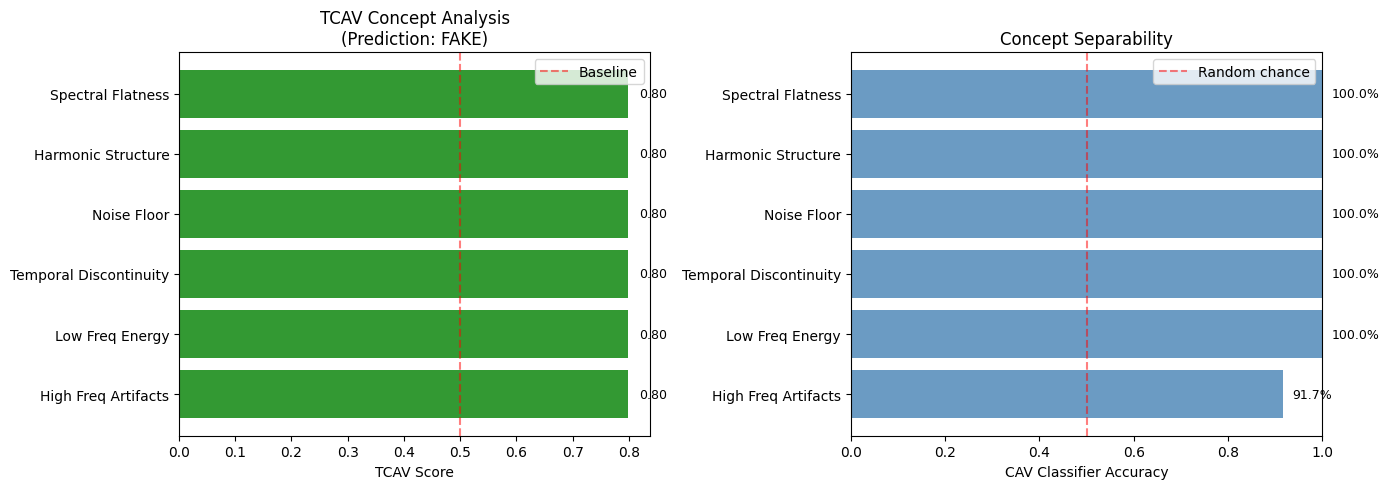


✓ XAI Analysis Complete!
Results saved to: explained_outputs
Close matplotlib windows to exit.



In [2]:
# TCAV analysis on a FAKE audio sample
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method tcav

Using device: cpu
Loading weights from: ./models/weights/EfficientNetB2_Attention_swa.pth

Running XAI Analysis on: EfficientNetB2_Attention_file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: tcav
Output directory: explained_outputs
Display mode: Interactive matplotlib windows

[TCAV] Running Concept-Based Analysis...
  Prediction: REAL (confidence: 80.7%)
  Explaining class: 1 (REAL)
     Selected EfficientNet features[-1]
     Refined Sequential to last Conv layer: Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  Using layer: Conv2d
  Testing 6 audio concepts...
  Processing concept: high_freq_artifacts
    CAV accuracy: 100.00%, TCAV score: 0.807
  Processing concept: low_freq_energy
    CAV accuracy: 100.00%, TCAV score: 0.807
  Processing concept: temporal_discontinuity
    CAV accuracy: 100.00%, TCAV score: 0.807
  Processing concept: noise_floor
    CAV accuracy: 100.00%, TCAV score: 0.807
  Processing concept: harmonic_structure
    CAV accuracy: 10

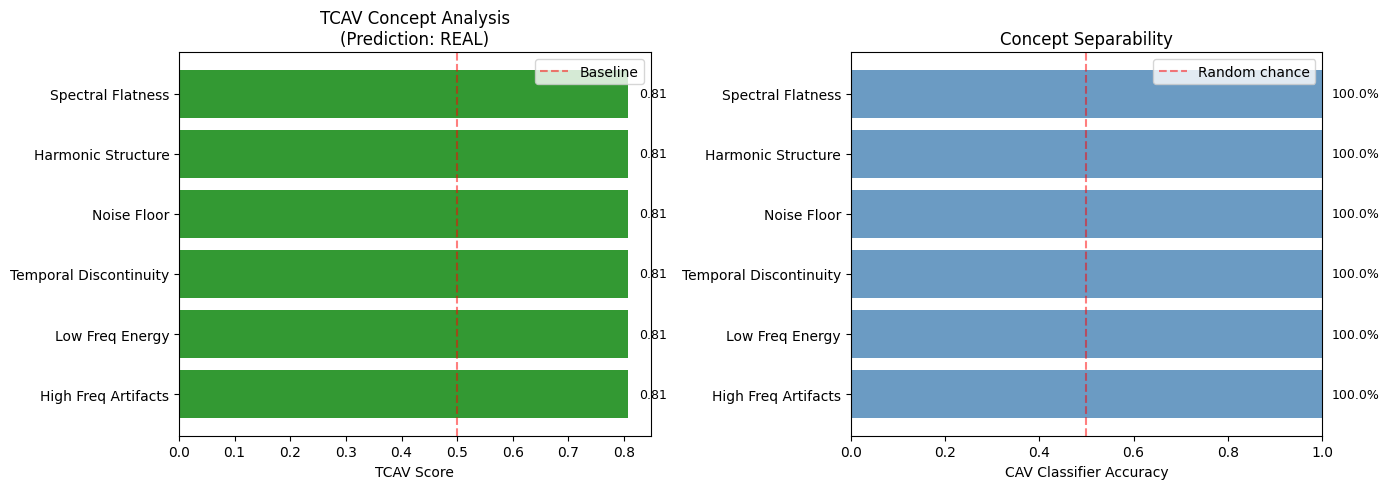


✓ XAI Analysis Complete!
Results saved to: explained_outputs
Close matplotlib windows to exit.



In [3]:
# TCAV analysis on a REAL audio sample
%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/real/file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method tcav

Using device: cpu
Loaded sub-model[0]: LCNN (variant: None)
Loaded sub-model[1]: SEResNet (variant: None)
Loaded sub-model[2]: EfficientNetB2 (variant: attention)
Created ensemble with 3 models
Loading weights from: ./models/weights/ensemble_swa.pth
Note: 4 projection parameters initialized randomly (architecture-dependent)

Running XAI Analysis on: ensemble_file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: tcav
Output directory: explained_outputs
Display mode: Interactive matplotlib windows

[TCAV] Running Concept-Based Analysis...
  Prediction: FAKE (confidence: 72.3%)
  Explaining class: 0 (FAKE)
  Ensemble detected, searching for best sub-model target...
  Using sub-model: ModelWithAttention
     Selected EfficientNet features[-1]
     Refined Sequential to last Conv layer: Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  Using layer: Conv2d
  Testing 6 audio concepts...
  Processing concept: high_freq_artifacts
    CAV accuracy: 100.00%, TCAV score: 

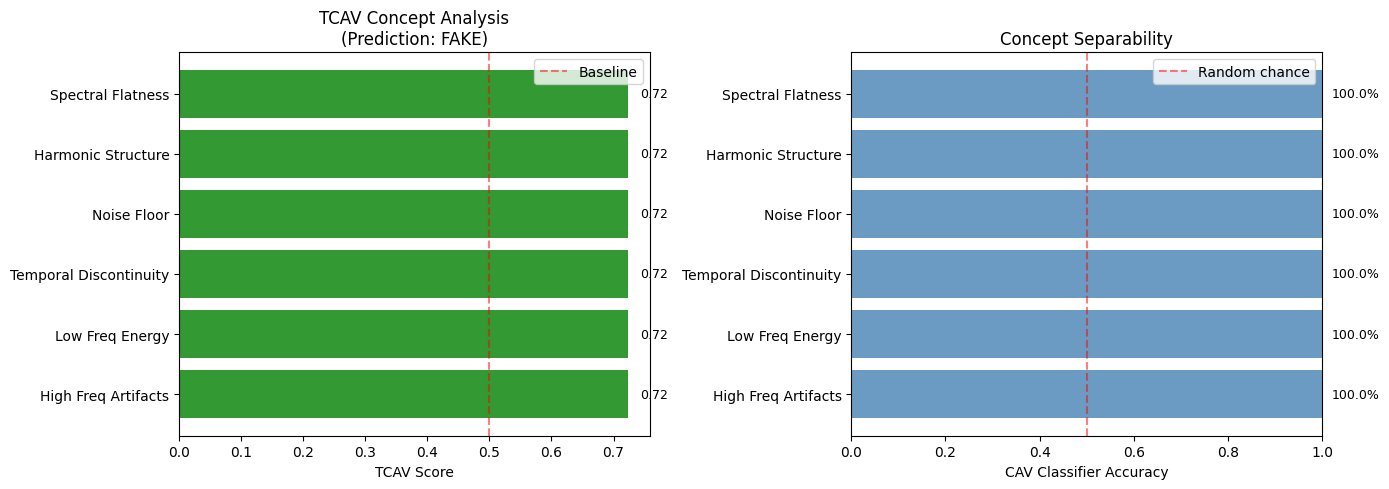


✓ XAI Analysis Complete!
Results saved to: explained_outputs
Close matplotlib windows to exit.



In [1]:
# TCAV analysis with ensemble model on FAKE audio
%run explain.py --config config/ensemble.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method tcav

Using device: cpu
Loaded sub-model[0]: LCNN (variant: None)
Loaded sub-model[1]: SEResNet (variant: None)
Loaded sub-model[2]: EfficientNetB2 (variant: attention)
Created ensemble with 3 models
Loading weights from: ./models/weights/ensemble_swa.pth
Note: 4 projection parameters initialized randomly (architecture-dependent)

Running XAI Analysis on: ensemble_file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: tcav
Output directory: explained_outputs
Display mode: Interactive matplotlib windows

[TCAV] Running Concept-Based Analysis...
  Prediction: REAL (confidence: 60.1%)
  Explaining class: 1 (REAL)
  Ensemble detected, searching for best sub-model target...
  Using sub-model: ModelWithAttention
     Selected EfficientNet features[-1]
     Refined Sequential to last Conv layer: Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  Using layer: Conv2d
  Testing 6 audio concepts...
  Processing concept: high_freq_artifacts
    CAV accuracy: 100.00%, TCAV score: 0

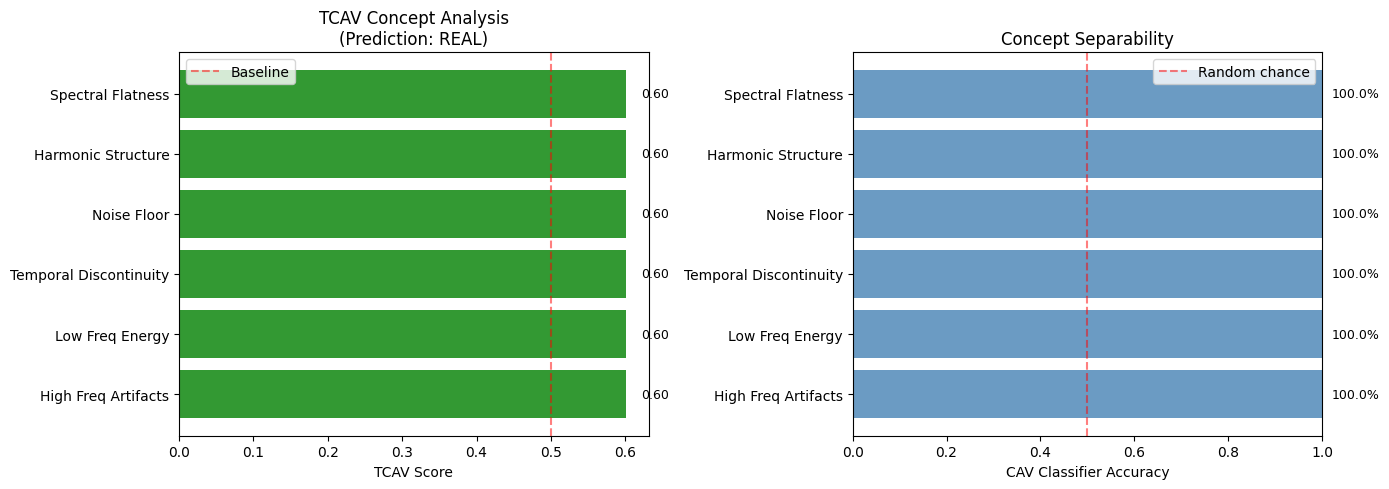


✓ XAI Analysis Complete!
Results saved to: explained_outputs
Close matplotlib windows to exit.



In [4]:
# TCAV ensemble on a REAL audio sample
%run explain.py --config config/ensemble.conf --feature_type 1 --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/real/file5.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --show --method tcav

### Interpreting TCAV Results

The TCAV analysis provides two key metrics:

1. **CAV Classifier Accuracy**: How well the concept can be distinguished in the model's internal representations
   - >60%: Concept is well-separated (meaningful)
   - ~50%: Random chance (concept not learned by model)

2. **TCAV Score**: Sensitivity of the prediction to the concept direction
   - Higher score = concept more relevant for this prediction
   - Scores are relative - compare across concepts for the same input

**Common patterns in deepfake detection:**
- FAKE audio often shows high importance for "high-frequency artifacts" and "temporal discontinuity"
- REAL audio typically shows higher "harmonic structure" importance